# Post-hoc Checkpoint Evaluation Across Perturbation Settings

In [1]:
import os
import re

import numpy as np
import pandas as pd
import scanpy as sc
import matplotlib.pyplot as plt

import torch
import torch_geometric
from sklearn.metrics import roc_auc_score

from SDAN.preprocess import qc, construct_GNN, construct_labels
from SDAN.layers import PoolSuper

SEED = 888
np.random.seed(SEED)
torch.manual_seed(SEED)


/Users/zxlin/Documents/GitHub/SDAN/venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Parameters
data_dir = './Zheng_2017/'
cell_types = ['cd4_t_helper', 'naive_t']
n_top_genes = 1000


In [3]:
def discover_annotation_robustness_files(output_dir, cell_type_str, n_top_genes=1000):
    pattern = re.compile(
        rf'^annotation_robustness_{re.escape(cell_type_str)}_dehvg_top{n_top_genes}_annotation_perturb([0-9]+(?:p[0-9]+)?)\.csv$'
    )
    rows = []
    for fn in os.listdir(output_dir):
        m = pattern.match(fn)
        if m is None:
            continue
        frac_str = m.group(1)
        frac = float(frac_str.replace('p', '.'))
        rows.append({'filename': fn, 'run_label': f'annotation_perturb{frac_str}', 'perturb_fraction': frac})
    return pd.DataFrame(rows).sort_values('perturb_fraction').reset_index(drop=True)
def load_biogrid_edges():
    candidates = [
        './Annotation/BIOGRID-ORGANISM-Homo_sapiens-4.4.204.tab3.txt.gz',
        './Annotation/BIOGRID-ORGANISM-Homo_sapiens-4.4.204.tab3.txt',
    ]
    biogrid_path = next((p for p in candidates if os.path.exists(p)), None)
    if biogrid_path is None:
        raise FileNotFoundError('Could not find BIOGRID file in ./Annotation/ (.txt.gz or .txt)')
    return pd.read_csv(
        biogrid_path,
        sep='\t',
        low_memory=False,
        usecols=['Official Symbol Interactor A', 'Official Symbol Interactor B'],
        dtype='string',
    )
def construct_gene_graph_cached(gene_list, biogrid_edges):
    mapping = pd.Series(range(len(gene_list)), index=gene_list)
    edge_df = biogrid_edges[
        (biogrid_edges['Official Symbol Interactor A'].isin(gene_list)) &
        (biogrid_edges['Official Symbol Interactor B'].isin(gene_list))
    ]
    edge_index = torch.as_tensor(
        np.vstack([
            edge_df.iloc[:, 0].map(mapping).to_numpy(dtype=np.int64),
            edge_df.iloc[:, 1].map(mapping).to_numpy(dtype=np.int64),
        ]),
        dtype=torch.long,
    )
    edge_index = torch.unique(edge_index, dim=1)
    edge_index = torch_geometric.utils.to_undirected(edge_index)
    edge_index, _ = torch_geometric.utils.remove_self_loops(edge_index)
    return edge_index
def _unique_undirected_pairs(edge_index):
    src = edge_index[0].detach().cpu().numpy()
    dst = edge_index[1].detach().cpu().numpy()
    pairs = np.stack([src, dst], axis=1)
    pairs = np.sort(pairs, axis=1)
    pairs = pairs[pairs[:, 0] != pairs[:, 1]]
    if pairs.size == 0:
        return np.empty((0, 2), dtype=np.int64)
    return np.unique(pairs, axis=0)
def perturb_edge_index(edge_index, num_nodes, frac, seed):
    if frac <= 0:
        return edge_index
    pairs = _unique_undirected_pairs(edge_index)
    m = len(pairs)
    if m == 0:
        return edge_index
    rng = np.random.default_rng(seed)
    k = int(round(frac * m))
    k = min(max(k, 0), m)
    if k == 0:
        out_pairs = pairs
    else:
        replace_idx = rng.choice(m, size=k, replace=False)
        keep_mask = np.ones(m, dtype=bool)
        keep_mask[replace_idx] = False
        keep_pairs = pairs[keep_mask]
        existing = {tuple(p) for p in keep_pairs.tolist()}
        new_pairs = []
        while len(new_pairs) < k:
            need = k - len(new_pairs)
            a = rng.integers(0, num_nodes, size=need * 4 + 32, dtype=np.int64)
            b = rng.integers(0, num_nodes, size=need * 4 + 32, dtype=np.int64)
            mask = a != b
            a = a[mask]
            b = b[mask]
            lo = np.minimum(a, b)
            hi = np.maximum(a, b)
            for u, v in zip(lo, hi):
                key = (int(u), int(v))
                if key in existing:
                    continue
                existing.add(key)
                new_pairs.append(key)
                if len(new_pairs) >= k:
                    break
        out_pairs = np.vstack([keep_pairs, np.array(new_pairs, dtype=np.int64)])
    src = np.concatenate([out_pairs[:, 0], out_pairs[:, 1]])
    dst = np.concatenate([out_pairs[:, 1], out_pairs[:, 0]])
    out = torch.as_tensor(np.vstack([src, dst]), dtype=torch.long)
    out, _ = torch_geometric.utils.remove_self_loops(out)
    out = torch.unique(out, dim=1)
    return out
def infer_poolsuper_dims(state_dict):
    in_channels = state_dict['conv1.lin_rel.weight'].shape[1]
    hidden1 = state_dict['conv1.lin_rel.weight'].shape[0]
    hidden2 = state_dict['conv2.lin_rel.weight'].shape[0]
    n_comp = state_dict['pool.weight'].shape[0]
    out_channels = state_dict['linear_relu_stack.9.weight'].shape[0]
    return in_channels, hidden1, hidden2, n_comp, out_channels
def compute_posthoc_losses_like_trainpy(state_path, train_GNN, val_GNN, test_GNN, train_labels, val_labels, test_labels, graph_weight):
    """Mirror SDAN/train.py loss computation semantics:
    - graph_loss from model(train_GNN)
    - clf losses on train (direct logits) and val/test using train_s projection
    """
    state_dict = torch.load(state_path, map_location='cpu')
    in_channels, hidden1, hidden2, n_comp, out_channels = infer_poolsuper_dims(state_dict)
    model = PoolSuper(in_channels, hidden1, hidden2, n_comp, out_channels)
    model.load_state_dict(state_dict)
    model.eval()
    criterion = torch.nn.CrossEntropyLoss()
    with torch.no_grad():
        # train forward gives train_s and graph losses
        train_logits, train_s, mc_loss, o_loss = model(train_GNN)
        graph_loss = graph_weight * mc_loss + graph_weight * o_loss
        train_clf_loss = criterion(train_logits, train_labels)
        # val/test logits use same train_s as in train.py
        val_reduced = val_GNN.x.t() @ train_s
        val_logits = model.linear_relu_stack(val_reduced)
        val_clf_loss = criterion(val_logits, val_labels)
        test_reduced = test_GNN.x.t() @ train_s
        test_logits = model.linear_relu_stack(test_reduced)
        test_clf_loss = criterion(test_logits, test_labels)
    return (
        float(mc_loss.item()),
        float(o_loss.item()),
        float(train_clf_loss.item()),
        float(val_clf_loss.item()),
        float(test_clf_loss.item()),
    )


In [4]:
d = data_dir
output_dir = os.path.join(d, 'output/check_graph')
check_dir = os.path.join(d, 'check_weight')
os.makedirs(check_dir, exist_ok=True)
cell_type_str = '-'.join(cell_types)
run_df = discover_annotation_robustness_files(output_dir, cell_type_str, n_top_genes=n_top_genes)
if run_df.empty:
    raise FileNotFoundError(f'No annotation_robustness files found in {output_dir} for {cell_type_str}.')
print('Detected settings:')
print(run_df[['perturb_fraction', 'run_label', 'filename']].to_string(index=False))
# Recreate train/val/test split exactly as check_graph.py
train_data_all = sc.read(f'{d}sc9_train.h5ad')
test_data = sc.read(f'{d}sc9_test.h5ad')
qc(train_data_all)
qc(test_data)
train_data_all = train_data_all[train_data_all.obs.cell_type.isin(cell_types), :]
test_data = test_data[test_data.obs.cell_type.isin(cell_types), :]
np.random.seed(SEED)
val_mask = np.zeros(len(train_data_all), dtype=bool)
val_mask[np.random.choice(len(train_data_all), int(np.floor(0.1 * len(train_data_all))), replace=False)] = True
val_data = train_data_all[val_mask]
train_data = train_data_all[~val_mask]
train_labels = construct_labels(train_data, cell_types)
val_labels = construct_labels(val_data, cell_types)
test_labels = construct_labels(test_data, cell_types)
biogrid_edges = load_biogrid_edges()
records = []
for _, run in run_df.iterrows():
    run_label = run['run_label']
    setting = run_label
    frac = float(run['perturb_fraction'])
    robust_csv = pd.read_csv(os.path.join(output_dir, run['filename']))
    graph_weight = float(robust_csv.loc[0, 'graph_weight'])
    gene_list_path = os.path.join(output_dir, f'gene_list_{cell_type_str}_{run_label}.txt')
    state_path = os.path.join(output_dir, f'state_{cell_type_str}_{run_label}.pt')
    if not os.path.exists(gene_list_path):
        raise FileNotFoundError(gene_list_path)
    if not os.path.exists(state_path):
        raise FileNotFoundError(state_path)
    gene_list = pd.Index(pd.read_csv(gene_list_path, header=None).squeeze())
    base_edge_index = construct_gene_graph_cached(gene_list, biogrid_edges)
    edge_index = perturb_edge_index(
        base_edge_index,
        num_nodes=len(gene_list),
        frac=frac,
        seed=SEED,
    )
    train_GNN = construct_GNN(train_data, gene_list, edge_index)
    val_GNN = construct_GNN(val_data, gene_list, edge_index)
    test_GNN = construct_GNN(test_data, gene_list, edge_index)
    mc_loss, o_loss, train_clf_loss, val_clf_loss, test_clf_loss = compute_posthoc_losses_like_trainpy(
        state_path=state_path,
        train_GNN=train_GNN,
        val_GNN=val_GNN,
        test_GNN=test_GNN,
        train_labels=train_labels,
        val_labels=val_labels,
        test_labels=test_labels,
        graph_weight=graph_weight,
    )
    records.append({
        'setting': setting,
        'perturb_fraction': frac,
        'graph_weight': graph_weight,
        'mc_loss': mc_loss,
        'o_loss': o_loss,
        'train_clf_loss': train_clf_loss,
        'val_clf_loss': val_clf_loss,
        'test_clf_loss': test_clf_loss,
    })
posthoc_df = pd.DataFrame(records).sort_values('perturb_fraction').reset_index(drop=True)
graph_loss_plot = posthoc_df['graph_weight'] * (posthoc_df['mc_loss'] + posthoc_df['o_loss'])
# Figure requested: 4 lines (graph_loss + clf_loss on train/val/test)
plt.figure(figsize=(7, 4), dpi=300)
plt.plot(posthoc_df['perturb_fraction'], graph_loss_plot, marker='o', label='graph_loss')
plt.plot(posthoc_df['perturb_fraction'], posthoc_df['train_clf_loss'], marker='o', label='train_clf_loss')
plt.plot(posthoc_df['perturb_fraction'], posthoc_df['val_clf_loss'], marker='o', label='val_clf_loss')
plt.plot(posthoc_df['perturb_fraction'], posthoc_df['test_clf_loss'], marker='o', label='test_clf_loss')
plt.xlabel('Perturbation fraction')
plt.ylabel('Loss')
plt.title('Post-hoc Loss Decomposition Across Settings')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
fig_path = os.path.join(check_dir, f'{cell_type_str}_loss_decomposition_posthoc.pdf')
plt.savefig(fig_path)
plt.close()
csv_path = os.path.join(output_dir, f'annotation_robustness_posthoc_loss_decomposition_{cell_type_str}.csv')
posthoc_df.to_csv(csv_path, index=False)
print(f'Saved figure: {fig_path}')
print(f'Saved summary: {csv_path}')
posthoc_df


Detected settings:
 perturb_fraction             run_label                                                                           filename
              0.0 annotation_perturb0p0 annotation_robustness_cd4_t_helper-naive_t_dehvg_top1000_annotation_perturb0p0.csv
              0.1 annotation_perturb0p1 annotation_robustness_cd4_t_helper-naive_t_dehvg_top1000_annotation_perturb0p1.csv
              0.2 annotation_perturb0p2 annotation_robustness_cd4_t_helper-naive_t_dehvg_top1000_annotation_perturb0p2.csv
              0.3 annotation_perturb0p3 annotation_robustness_cd4_t_helper-naive_t_dehvg_top1000_annotation_perturb0p3.csv
              0.4 annotation_perturb0p4 annotation_robustness_cd4_t_helper-naive_t_dehvg_top1000_annotation_perturb0p4.csv
              0.5 annotation_perturb0p5 annotation_robustness_cd4_t_helper-naive_t_dehvg_top1000_annotation_perturb0p5.csv
              0.6 annotation_perturb0p6 annotation_robustness_cd4_t_helper-naive_t_dehvg_top1000_annotation_perturb0p6.c

/Users/zxlin/Documents/GitHub/SDAN/SDAN/preprocess.py:107: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/torch/csrc/utils/tensor_numpy.cpp:219.)
  return torch.as_tensor(labels, dtype=torch.long)


The proportion of non-isolated genes: 0.88
The proportion of non-isolated genes: 0.88
The proportion of non-isolated genes: 0.88
The proportion of non-isolated genes: 0.98
The proportion of non-isolated genes: 0.98
The proportion of non-isolated genes: 0.98
The proportion of non-isolated genes: 0.99
The proportion of non-isolated genes: 0.99
The proportion of non-isolated genes: 0.99
The proportion of non-isolated genes: 1.00
The proportion of non-isolated genes: 1.00
The proportion of non-isolated genes: 1.00
The proportion of non-isolated genes: 1.00
The proportion of non-isolated genes: 1.00
The proportion of non-isolated genes: 1.00
The proportion of non-isolated genes: 1.00
The proportion of non-isolated genes: 1.00
The proportion of non-isolated genes: 1.00
The proportion of non-isolated genes: 1.00
The proportion of non-isolated genes: 1.00
The proportion of non-isolated genes: 1.00
The proportion of non-isolated genes: 1.00
The proportion of non-isolated genes: 1.00
The proport

,setting,perturb_fraction,graph_weight,mc_loss,o_loss,train_clf_loss,val_clf_loss,test_clf_loss
0,annotation_perturb0p0,0.0,1.0,-0.757237,0.306539,0.357487,0.447892,0.473679
1,annotation_perturb0p1,0.1,1.0,-0.956797,1.198638,0.365329,0.436687,0.464371
2,annotation_perturb0p2,0.2,1.0,-0.969343,1.255525,0.406986,0.444122,0.449098
3,annotation_perturb0p3,0.3,1.0,-0.981969,1.286495,0.446262,0.481084,0.478006
4,annotation_perturb0p4,0.4,1.0,-0.981355,1.294551,0.386640,0.441405,0.444139
5,annotation_perturb0p5,0.5,1.0,-0.979434,1.294180,0.403592,0.451616,0.451187
6,annotation_perturb0p6,0.6,1.0,-0.980289,1.294553,0.457859,0.470562,0.472665
7,annotation_perturb0p7,0.7,1.0,-0.981450,1.294878,0.418967,0.441716,0.445369
8,annotation_perturb0p8,0.8,1.0,-0.983172,1.295296,0.419309,0.443457,0.447020
9,annotation_perturb0p9,0.9,1.0,-0.981960,1.294960,0.669463,0.653885,0.675222


In [5]:
# Plot test AUC across settings by reading saved annotation_robustness CSVs
auc_rows = []
for _, run in run_df.iterrows():
    fpath = os.path.join(output_dir, run['filename'])
    df = pd.read_csv(fpath)
    auc_rows.append({
        'setting': df.loc[0, 'setting'],
        'perturb_fraction': float(df.loc[0, 'perturb_fraction']),
        'test_auc': float(df.loc[0, 'test_auc']),
    })

auc_from_csv_df = pd.DataFrame(auc_rows).sort_values('perturb_fraction').reset_index(drop=True)

plt.figure(figsize=(6, 4), dpi=300)
plt.plot(auc_from_csv_df['perturb_fraction'], auc_from_csv_df['test_auc'], marker='o')
best_idx = auc_from_csv_df['test_auc'].idxmax()
plt.scatter(auc_from_csv_df.loc[best_idx, 'perturb_fraction'], auc_from_csv_df.loc[best_idx, 'test_auc'], s=40)
plt.xlabel('Perturbation fraction')
plt.ylabel('Test AUC')
plt.title('Test AUC Across Settings (Saved CSV)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
test_auc_fig_path = os.path.join(check_dir, f'{cell_type_str}_test_auc_from_saved_csv.pdf')
plt.savefig(test_auc_fig_path)
plt.close()

print(f'Saved test-AUC figure: {test_auc_fig_path}')
auc_from_csv_df.sort_values('test_auc', ascending=False)


Saved test-AUC figure: ./Zheng_2017/check_weight/cd4_t_helper-naive_t_test_auc_from_saved_csv.pdf


,setting,perturb_fraction,test_auc
5,annotation_perturb0p5,0.5,0.885436
10,annotation_perturb1p0,1.0,0.882206
4,annotation_perturb0p4,0.4,0.878376
7,annotation_perturb0p7,0.7,0.874713
8,annotation_perturb0p8,0.8,0.872204
2,annotation_perturb0p2,0.2,0.867423
3,annotation_perturb0p3,0.3,0.865882
0,annotation_perturb0p0,0.0,0.864980
1,annotation_perturb0p1,0.1,0.862096
9,annotation_perturb0p9,0.9,0.859759


/Users/zxlin/Documents/GitHub/SDAN/venv/lib/python3.10/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


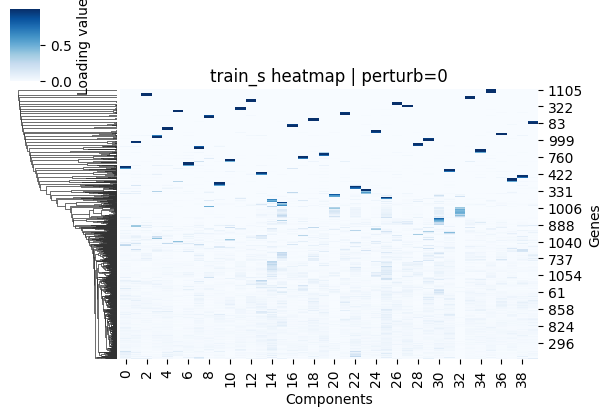

/Users/zxlin/Documents/GitHub/SDAN/venv/lib/python3.10/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


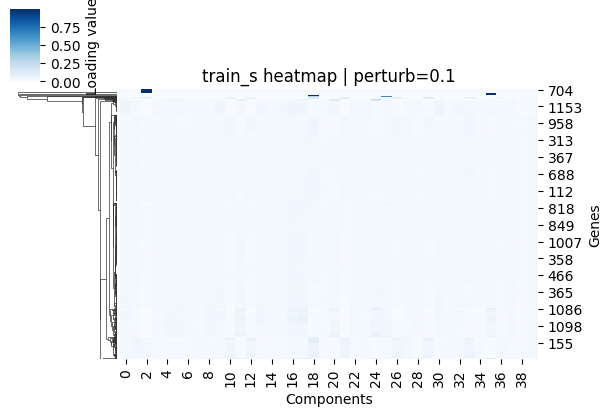

/Users/zxlin/Documents/GitHub/SDAN/venv/lib/python3.10/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


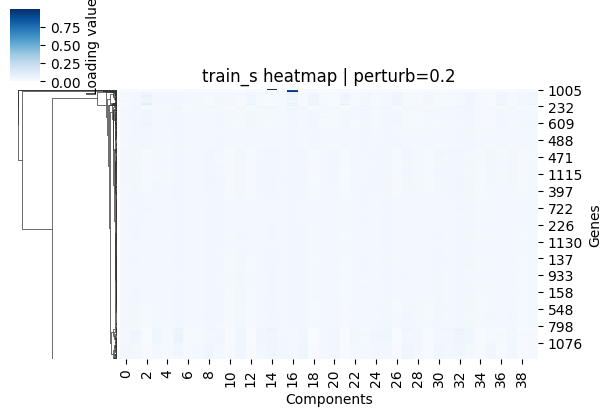

/Users/zxlin/Documents/GitHub/SDAN/venv/lib/python3.10/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


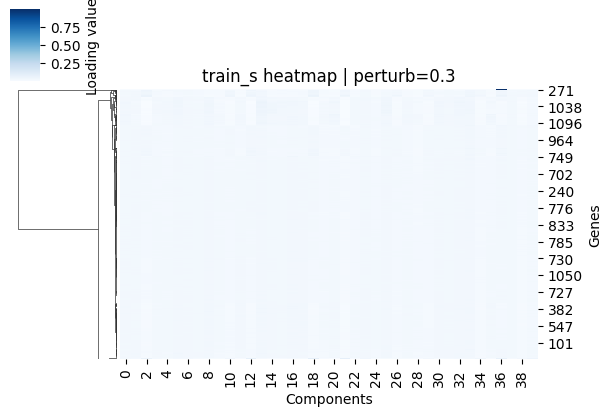

/Users/zxlin/Documents/GitHub/SDAN/venv/lib/python3.10/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


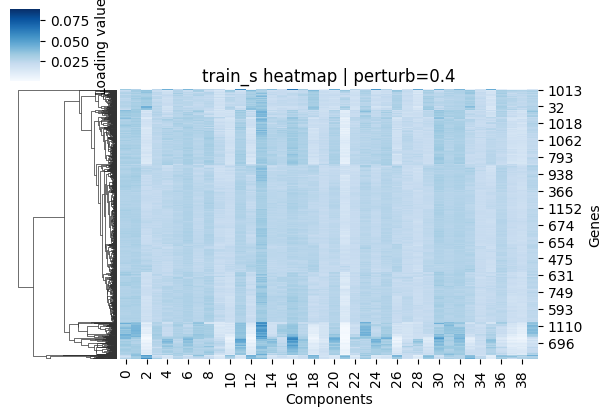

/Users/zxlin/Documents/GitHub/SDAN/venv/lib/python3.10/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


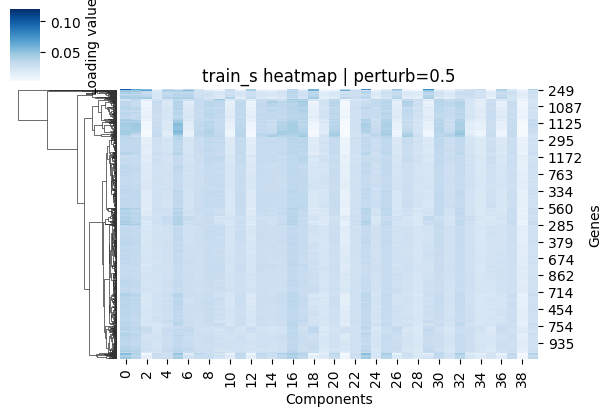

/Users/zxlin/Documents/GitHub/SDAN/venv/lib/python3.10/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


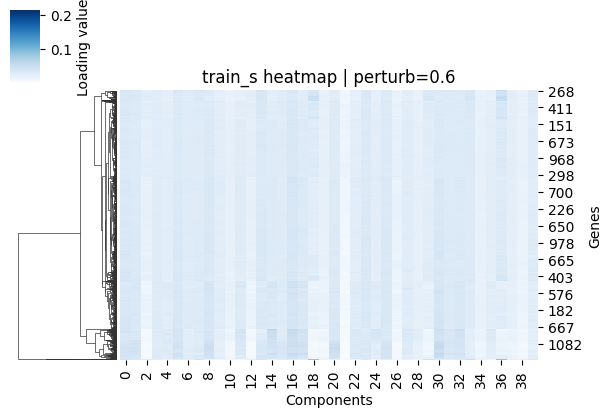

/Users/zxlin/Documents/GitHub/SDAN/venv/lib/python3.10/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


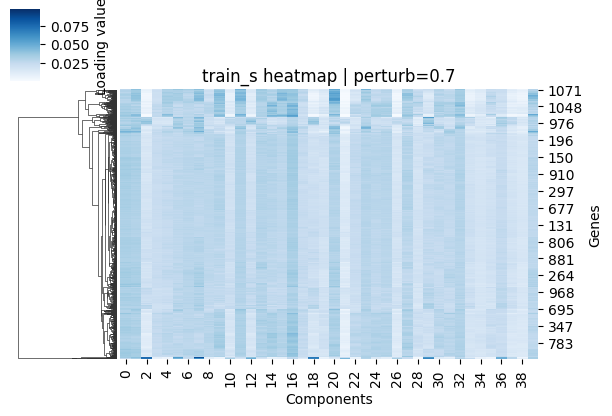

/Users/zxlin/Documents/GitHub/SDAN/venv/lib/python3.10/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


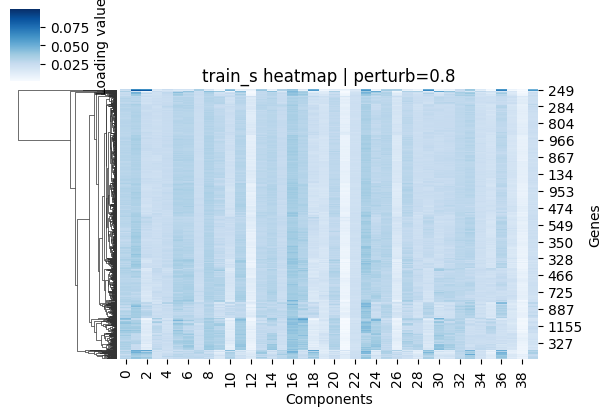

/Users/zxlin/Documents/GitHub/SDAN/venv/lib/python3.10/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


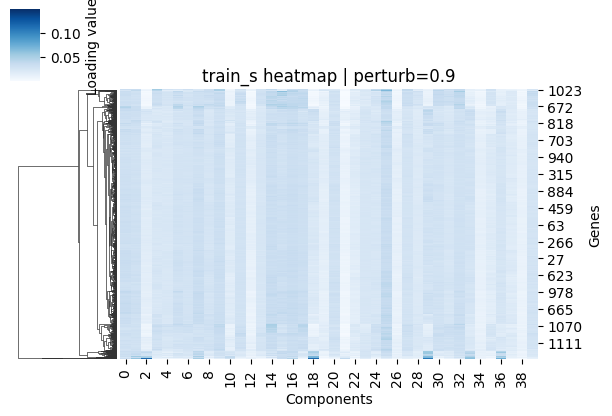

/Users/zxlin/Documents/GitHub/SDAN/venv/lib/python3.10/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


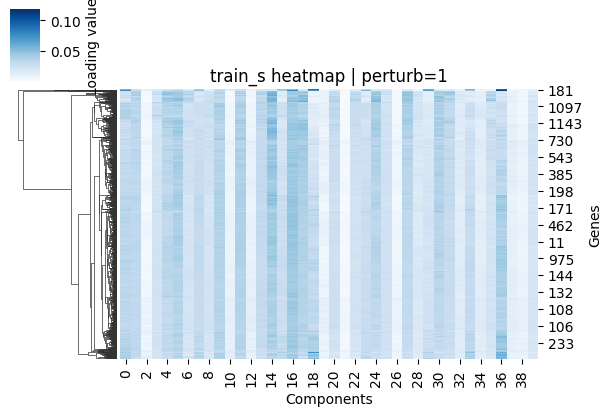

In [6]:
# Visualize train_s heatmap for each setting using the same style as plot_s (display only, no save)
import seaborn as sns

for _, run in run_df.sort_values('perturb_fraction').iterrows():
    run_label = run['run_label']
    frac = float(run['perturb_fraction'])
    s_path = os.path.join(output_dir, f'train_s_{cell_type_str}_{run_label}.npy')
    if not os.path.exists(s_path):
        print(f'Skip missing file: {s_path}')
        continue

    train_s = np.load(s_path)
    g = sns.clustermap(train_s, col_cluster=False, cmap='Blues', figsize=(6, 4))
    g.ax_heatmap.set_title(f'train_s heatmap | perturb={frac:g}')
    g.ax_heatmap.set_xlabel('Components')
    g.ax_heatmap.set_ylabel('Genes')
    g.cax.set_ylabel('Loading value')
    plt.show()
    plt.close(g.fig)


In [7]:
# Hoyer sparsity plot across perturbation settings (refer to SDAN-v2/plots.ipynb)
import seaborn as sns

def hoyer_sparsity(v):
    v = np.abs(np.asarray(v, dtype=float).ravel())
    l2 = np.linalg.norm(v, 2)
    if l2 == 0:
        return 0.0
    n = len(v)
    return (np.sqrt(n) - np.linalg.norm(v, 1) / l2) / (np.sqrt(n) - 1 + 1e-12)

def compute_gene_hoyer(L):
    return np.array([hoyer_sparsity(L[i, :]) for i in range(L.shape[0])], dtype=float)

dfs = []
for _, run in run_df.iterrows():
    run_label = run['run_label']
    frac = float(run['perturb_fraction'])
    s_path = os.path.join(output_dir, f'train_s_{cell_type_str}_{run_label}.npy')
    if not os.path.exists(s_path):
        raise FileNotFoundError(s_path)
    L = np.load(s_path, allow_pickle=True)
    if getattr(L, 'dtype', None) == object:
        L = np.array([np.asarray(r, float).ravel() for r in L])
    h = compute_gene_hoyer(L)
    dfs.append(pd.DataFrame({'Hoyer': h, 'Setting': f'{frac:g}'}))

hoyer_df = pd.concat(dfs, ignore_index=True)
order = [f'{x:g}' for x in sorted(run_df['perturb_fraction'].tolist())]

plt.figure(figsize=(6.2, 3.6), dpi=300)
sns.violinplot(data=hoyer_df, x='Setting', y='Hoyer', order=order, inner=None, cut=0, linewidth=0.8, width=0.7)
sns.boxplot(data=hoyer_df, x='Setting', y='Hoyer', order=order, width=0.22, showfliers=False,
            boxprops={'facecolor': (0, 0, 0, 0), 'edgecolor': 'black', 'linewidth': 1.0},
            whiskerprops={'linewidth': 1.0}, medianprops={'color': 'black', 'linewidth': 1.1})
plt.xlabel('Perturbation fraction')
plt.ylabel('Hoyer Sparsity')
plt.ylim(0, 1.0)
plt.grid(True, axis='y', alpha=0.25)
plt.tight_layout()
hoyer_fig_path = os.path.join(check_dir, f'{cell_type_str}_hoyer_sparsity_posthoc.pdf')
plt.savefig(hoyer_fig_path)
plt.close()

hoyer_summary_df = (
    hoyer_df.groupby('Setting', as_index=False)
    .agg(mean_hoyer=('Hoyer', 'mean'), median_hoyer=('Hoyer', 'median'), std_hoyer=('Hoyer', 'std'))
)
hoyer_summary_df['Setting_num'] = hoyer_summary_df['Setting'].astype(float)
hoyer_summary_df = hoyer_summary_df.sort_values('Setting_num').drop(columns=['Setting_num']).reset_index(drop=True)
hoyer_csv_path = os.path.join(output_dir, f'annotation_robustness_hoyer_summary_{cell_type_str}.csv')
hoyer_summary_df.to_csv(hoyer_csv_path, index=False)

print(f'Saved hoyer sparsity figure: {hoyer_fig_path}')
print(f'Saved hoyer summary: {hoyer_csv_path}')
hoyer_summary_df


Saved hoyer sparsity figure: ./Zheng_2017/check_weight/cd4_t_helper-naive_t_hoyer_sparsity_posthoc.pdf
Saved hoyer summary: ./Zheng_2017/output/check_graph/annotation_robustness_hoyer_summary_cd4_t_helper-naive_t.csv


,Setting,mean_hoyer,median_hoyer,std_hoyer
0,0,0.669179,0.732125,0.314654
1,0.1,0.092298,0.033617,0.173509
2,0.2,0.053489,0.021250,0.106117
3,0.3,0.028590,0.012978,0.054850
4,0.4,0.026693,0.014424,0.031972
5,0.5,0.041348,0.027288,0.040474
6,0.6,0.046104,0.031839,0.043397
7,0.7,0.040062,0.027650,0.035567
8,0.8,0.049644,0.043090,0.027873
9,0.9,0.057577,0.048024,0.035398
